## Del 1

**Oppgave 1**

$$A = \begin{bmatrix}  1 & -1 \\ 1 & -0.6 \\ 1 & -0.2 \\ 1 & 0.2 \\ 1 & 0.6 \\ 1 & 1  \end{bmatrix}$$ har dim=(6x2), 6 rader 2 kolonner.

c = $\begin{bmatrix}  c_1  \\ c_2 \end{bmatrix}$, som er de parameterne foran $t$ har dim=(2x1).

B er målepunktene (kjente punkter tilhørende hver verdi t). Denne har dim: $(6x2)(2x1) = (6x1)$.

Residualen blir:$$r = \begin{bmatrix} 0.03 \\ 0.05 \\ -0.05 \\ 0.15 \\ -0.06 \\ 0.13 \end{bmatrix}$$

Kvadratsummen blir: $0.04890000000000008$

Hvis målingen har positiv residual ligger den over den foreslåtte grafen, hvis den er negativ under og 0 hvis den er på grafen. Her blir det målingene ved $t= -1, -0.6, 0.2, 1$

**Oppgave 2**
Ved bruk av MGS og QR faktorisering fant vi:
$$c_{qr} = [0.99166667 1.12642857]$$
Eller: $$c= \begin{bmatrix} c_1 \\ c_2 \end{bmatrix} = \begin{bmatrix} 0.99166667 \\ 1.12642857 \end{bmatrix} $$
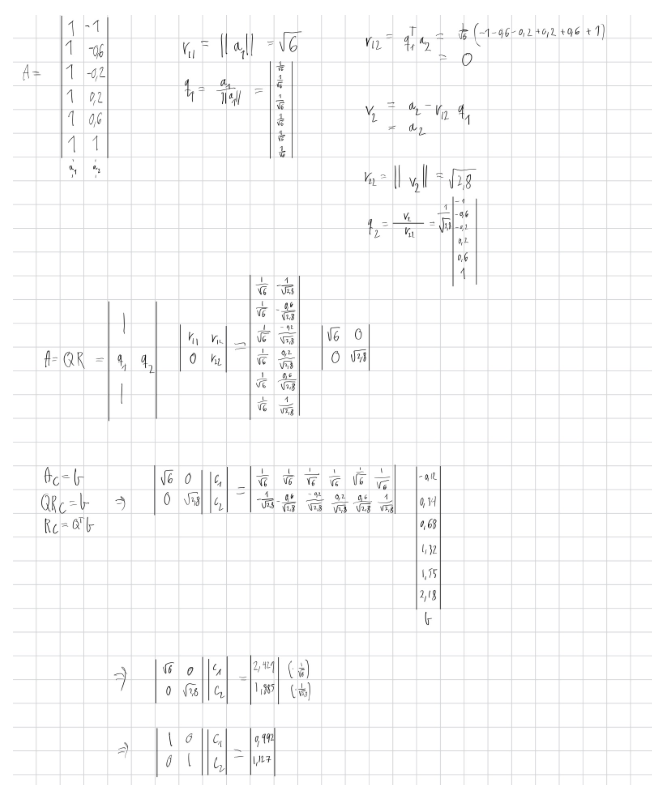

**Oppgave 3**
$Q^T Q -I$ sjekker om kolonne i $Q$ er ortonormale, resultatet blir en null matrise.
Frobenius normen av dette slår sammen avvike for alle elementene i matrisen til et tall, eller tapet av ortonormalitet.
$$|Q^T Q|_f= 2.230969341644725*10^{-16}$$

$A- QR$ sjekker differansen av matrisen $A$ og den faktoriserte matrisen $QR$.
Frobenius normen av dette måler om faktorene bygger opp $A$ igjen.
$$|A - Q R|_f= 1.594436429147036*10^{-16}$$


$Q^Tr$  gir for hver kolonne $q_i$ i $Q$, mengden av residualen som peker i retningen $q_i$.
Formen $x^Tv$ sier hvor mye av $x$ som peker i den valgte retningen $v$, når v har lengde 1. $$q^T_ir =r^Tq_i$$$q$ har lengde 1.
For c vi fant får vi tilnærmet $Q^Tr \approx [0,0]$, mens for $$Q^Tr_{try}= \begin{bmatrix} 0.102 \\ 0.442 \end{bmatrix}$$ Siden det ikke er en null-kolonne, og siden QR spenner ut $A$. Kan denne delen alltid fjernes, dermed har vi ikke en optimal løsning.

**Oppgave 4**
Hvis residualene ikke er 0, vi treffer ikke alle punktene, men QR-kontrollene er gode, $A=QR$ er pålitelig. Hvis vi o tillegg har at $Q^Tr \approx 0$ ligger feilen vinkelrett på kolonnerommet (til $A$). Vi har derfor funnet den beste lstsq løsningen.

## Del 2

**Oppgave 1**
$$
B = \begin{bmatrix}
1 & 0 & 1 \\
0 & 1 & 1 \\
0 & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$
Her er $a_3 = a_1 + a_2$, dermed er $a_3$ LA av $a_1, a_2$.  Når CGS trekker fra projeksjonene på $q_i$ blir det 0:
$v = a_j - \sum (q^T_ia_j) q_i =0$, og dermed $r_{jj} = |v| = 0$. Demerd blir det delig på 0 når du normalisere $q_j=\frac{v}{r_{jj}}$.  Her blir det: $$Q[:, j] = v / R[j, j]$$ med $j=2$ (kolonne 3).

**Oppgave 2**
Med $\delta = [10^{-4}, 10^{-10}, 10^{-16}]$, vil vi får tre forskjellige og LU $a_3$ kolonner.
Vi får:  $$a_3 = \begin{bmatrix}
1 \\
1 \\
\delta \\
0
\end{bmatrix}$$
Her får vi:
 δ = 1e-04
- **Klassisk GS:** `diag(R) = [1.e+00, 1.e+00, 1.e-04]`
  - Endelige verdier: `True`
- **Modifisert GS:** `diag(R) = [1.e+00, 1.e+00, 1.e-04]`
  - Endelige verdier: `True`

#### δ = 1e-10
- **Klassisk GS:** `diag(R) = [1.e+00, 1.e+00, 1.e-10]`
  - Endelige verdier: `True`
- **Modifisert GS:** `diag(R) = [1.e+00, 1.e+00, 1.e-10]`
  - Endelige verdier: `True`

#### δ = 1e-16
- **Klassisk GS:** `diag(R) = [1.e+00, 1.e+00, 1.e-16]`
  - Endelige verdier: `True`
- **Modifisert GS:** Stoppet: *Kolonne 3 gir ingen pålitelig ny retning*

Fordi $\delta \neq 0$ blir $a_3$ LU, i eksakt regning med alle prøve verdiene for $\delta$.  CGS fullfører med endelige verdier i med alle $\delta$ verdiene, men MGS stopper for $\delta = 10^{-16}$. Dette er fordi lengden:
$$r_{33} = 10^{-16}$$ er mindre enn toleransen:
```
tolerance = np.finfo(float).eps * max(m, n) * np.linalg.norm(A, "fro")

# MGS, for kolonne j:
for i in range(j):
    R[i, j] = Q[:, i] @ v
    v = v - R[i, j]*Q[:, i] # trekker fra komponenten langs q_i, finner resten
R[j, j] = np.linalg.norm(v) # lengden av resten, r_jj

if R[j, j] <= tolerance:    # resten er for liten til å stole på
    raise np.linalg.LinAlgError(
        f"Kolonne {j+1} gir ingen pålitelig ny retning"
    )
Q[:, j] = v/R[j, j]         # normalisering
```


**Oppgave 3**
MGS har en sjekk på lengden til resten:
```
R[j, j] = np.linalg.norm(v)
if R[j, j] <= tolerance:
```
Dette hindrer normalisering, hvis  lengden er for liten:
```
Q[:, j] = v/R[j, j]
```
Altså vi stopper hvis resten ikke er nok til å gi en ny retning, vi er "numerisk-sett" lineært avhengig.

**Oppgave 4**
Gitt at vi har endelige verdier, tenk at vi også har en $QR$-faktorisering av A. Vi må bruke $A-QR$ og $Q^TQ-I$ , for å sjekke at vi ikke har mistet ortogonaltiet, og at vi faktisk rekonstruerer $A$.

Det kan vises at man kan ha endelige verdier i en $QR$-faktorisering uten at $QR$ rekonstruerer $A$ på en tilfredsstillende måte. Derfor er det ikke nok at alle verdiene er endelige.

Eks, bevis ved motbevis:
Gitt: $$A = \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix}$$
og QR: $$Q = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix} \qquad R = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$$
Sjekk først at $A-QR$ gir null matrisen (vi kan rekonstruer $A$ riktig):
$$QR = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}  \begin{bmatrix} 1 &1 \\ 0 & 1
\end{bmatrix} = \begin{bmatrix} 1 & 2 \\ 0 & 1 \end{bmatrix}$$
Vi får tilbake $A$, dermed må vi sjekke om vi beholder ortogonaliteten: $$Q^TQ = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}  \begin{bmatrix} 1 & 0 \\ 1 & 1
\end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 1 & 2 \end{bmatrix}$$
Dermed får vi ikke null matrisen når vi gjør $Q^TQ-I$.  Derfor er ikke det at vi har endelige verdier i $Q$ nok til å si om $QR$-faktoriseringen er pålitelig.

## Del 3
**Oppgave 1**
Vi har 12 rader, målepunkter/likninger, med verdier mellom -1 og 1.
```
m = 12 # rader
points = np.linspace(-1.0, 1.0, m) # mengden målepunkter
```
Vi har 4 kolonner, grad 3 Cheb, siden vi trenger 1 ekstra rad for T_0 koeffisieten. Altså 4 ukjente,
```
n = 3
C = chebyshev_matrix(points, n) # grad 3 chebyshev matrise T_0 +... + T_3, A
```
Vi får dermed: $p(t) = c_0T_0 + c_1T_1 +c_2T_2 +c_3T_3$
Første raden i $C$ er chebyshev i det første målepunktet $-1$:
```
print(points[0]) > -1.0 # første målepunkt
print(C[0]) > [ 1. -1.  1. -1.] # første rad i C

```
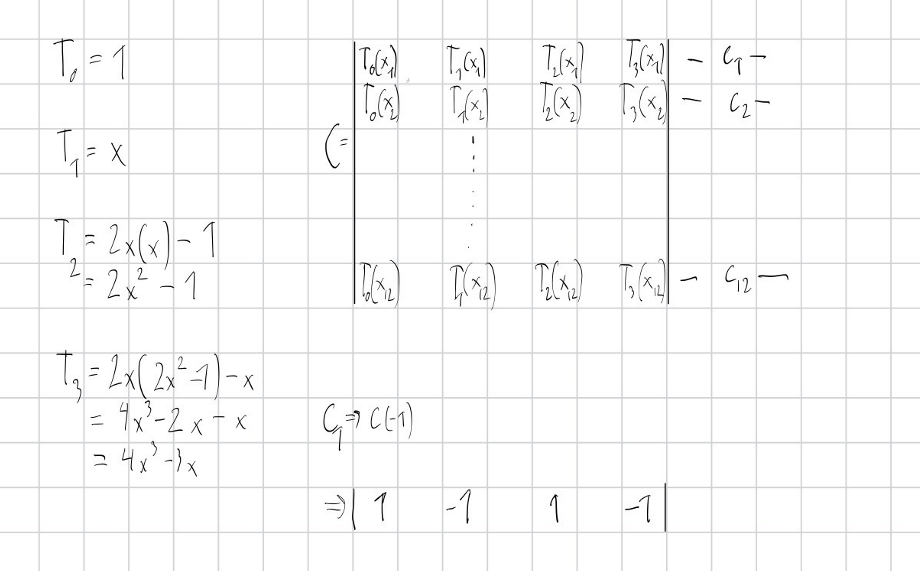


**Oppgave 2**
```
Residual i målepunktene (norm): 0.002536446189097725
Max error: 0.0008394590978579863
```
Vi må undersøke begge størrelsene:
- Residualen, og da også residual normen, ser kun på det som skjer i målepunktene. Den sier ingenting om det som skjer mellom målepunktene.
- Maks error sier noe om avviket mellom den sanne kurven og den tilpassede kurven på intervallet. Det kan hende vi er godt tilpasset når vi har  støy, men dårlig for den sanne kurven.

**Oppgave 3**
- Støy = 0
```
Residual i målepunktene: 1.5582722720639762e-15
Er kolonnen i Q ortonormale: 5.723108547048621e-16
Rekonstuerer vi C: 2.669445784096911e-16
Max error: 8.881784197001252e-16
```

- Støy = 1e-3
```
Residual i målepunktene: 0.002536446189097725
Er kolonnen i Q ortonormale: 5.723108547048621e-16
Rekonstuerer vi C: 2.669445784096911e-16
Max error: 0.0008394590978579863
```

- Støy = 1e-2
```
Residual i målepunktene: 0.025364461890977043
Er kolonnen i Q ortonormale: 5.723108547048621e-16
Rekonstuerer vi C: 2.669445784096911e-16
Max error: 0.008394590978580307
```
Det som endrer seg er max_error og residualen i målepunktene. Uten støy er de nær 0, dette skyldes flyttall regning, praksitsk talt er de 0.

Når error øker øker også max_error og residualene/residualnormen. Dette betyr at vi det tilpassede kruven skyves vekk fra den sanne kruven pga støyet. Og at kurven også skyves vekk fra målepunktene, økende residual.

$A-QR$ og $Q^TQ-I$ endres ikke fordi ikke avhenger av målingene, men bare av målepunktene.

**Oppgave 4**
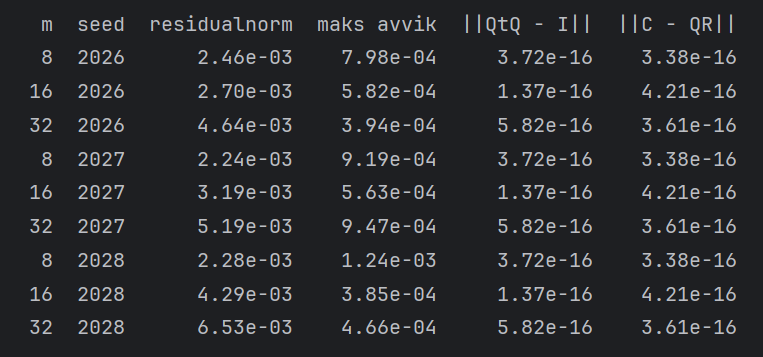
Vi ser at konklusjonen ikke er lik i alle forsøkene. Fra fra $m=8 \rightarrow m=16$ blir avvik mindre for all ter seeds.  Når vi går fra $m=16 \rightarrow m=32$ blir det bare bedre for $seed = 2026$, mens det blir verre for begge de to andre. Vi kan derfor ikke si at flere målinger alltid gir mindre kurvefeil.


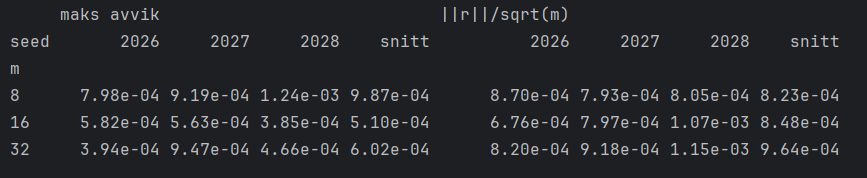

## del 4
**oppgave 1**
Forventer i eksakt regning atde beste modellverdiene ved målepunktene blir helt like mellom de to basissne. Dette er fordi vi beskriver samme polynomet,  punktene og målingene, og begge to er basiser for det samme polynomrommet.

**Oppgave 2**
 Med  støy får vi:
- Monomial-basis:
	- Absolutt kurvefeil i 1e-10 skala
	- Residual norm = 2.563e-10
	- Ortogonaltiet feil =  8.909e-13
	- Rekonstruksjons feil = 8.961e-17

- Chebyshev-basis:
	- Absolutt kurvefeil i 1e-15 skala
	- Residual norm = 2.563e-10
	- Ortogonalitets feil =  1.113e-15
	- Rekonstruksjons feil = 1.177e-16


**Oppgave 3**
 Uten  støy får vi:
- Monomial-basis:
	- Absolutt kurvefeil i 1e-13 skala
	- Residual norm = 3.431e-10
	- Ortogonaltiet feil = 8.909e-13
	- Rekonstruksjons feil = 8.961e-17

- Chebyshev-basis:
	- Absolutt kurvefeil i 1e-15 skala
	- Residual norm = 3.428e-10
	- Ortogonalitets feil =  1.113e-15
	- Rekonstruksjons feil = 1.177e-16

Når det legges til en noise faktor på $10^{-10}$  går vi fra en kurve feil på skala av $10^{-13}$ til $10^{-10}$ for monomial basis, og fra  $10^{-15}$ til  $10^{-10}$ for chebyshev basis

**Oppgave 4**
Vi får lik residual norm for begge metodene i begge basisene. "lstsq" gir rundt den samme maks kurvefeil i begge basisene, mens QR gir $1.002 * 10^{-10} - 9.978 * 10^{-11} \approx 4\cdot10^{-13},$ mindre for QR i monomial basis enn Chebyshev basis. Dette viser at kurvefeilen blir dominert av støyen, nesten hele kurve feilen kommer fra støyen i målingene.


## del 6
**oppgave 1**
$$\begin{aligned}
&\ \qquad A^T(b-Ac) = 0 \\
&\implies A^Tb - A^TAc = 0 \\
&\implies A^Tb = A^TAc \\
 &\ \qquad A^TAc = A^Tb
\end{aligned}$$
Her hvis vi sier at $A$ har $m$ rader og $n$ kolonner ($m \times n$), og at b er $(m\times 1)$ får vi:
$$\begin{aligned}
&\ (n \times m)(m \times n)c=(n \times m)(m \times 1)\\
&\implies (n \times n)c=(n \times  1) \\
&\implies c = (n \times 1)
\end{aligned}$$
Matrisen får dimensjon ($n \times n$), og høyresiden får dimensjon ($n \times 1$).
Siden oppgaven har valgt å definere matrsien som ($n \times m$), hvor $n=12+1$ er rader og $m=25$ er kolonner får vi:
$$(13 \times 13)(13\times1)=(13\times1)$$
**oppgave 2**
Vi ser at for:
- Grad 12 Med Chebyshevbasis gir normallikningene samme residual som QR og lstsq. Med monomialbasis gir QR og lstsq en litt mindre residual enn NE, men forskjellen er liten.
- Grad 16: Med Chebyshevbasis gir alle metodene samme residual. Med monomialbasis er residualen til NE ca. 45 ganger større enn for QR og lstsq, fordi $K(A^TA) = K(A)^2 \approx   4.6*10^{11}$.
- Grad 20: Med Chebyshevbasis gir alle metodene samme residual. Med monomialbasis er residualen til NE flere størrelsesordener større enn for QR og lstsq, siden $K(A^TA)=K(A)^2*\epsilon$ og nesten all presisjon er tapt. QR begynner også å bli merkbart dårligere enn lstsq.

Å bruke normallikningen til $A$ gir dårligere resultat (residual) i monomial basis, fordi $A^TA$ gir et kondisjonstall på $K(A)^2$. Å bruke Chebyshev basis hjelper, fordi $A$ blir bedre konisdjonert i Chebyshev basis.

## del 7
Fra del 6. brukte vi vår egne implementasjon av MGS, og np.linalg.lstsq. Når vi jobbet på normal likningen $A^T(b-Ac)=0$  for minste kvadraters metode, fikk vi dårligere resultat enn de metodene, som løste minstek vadraters direkte.

Vi velger å endre punkt fordeling fra jevt fordelte punkter, til chebyshev fordelte punkter. Dette skal kunne gi en bedre kondisjonert $A$, fordi punktene vil da ligge mere samlet langs endene (se uke 3, Del 3).

Vi ser at vi får resudert maks kurve feil, fra omtrent $5*10^{-9}$ til rundt $1.15 *10^{-9}$. Uten at konsidjonstallet til $A$ endres mye, vi ser en veldig liten minskning. Siden vi endrer punktene får vi en annen projeksjon.  Dette kan gi en større residual, bedre konisjonering gir ikke nødvedning vis lavere residual, lavere $K(A) \centernot\implies$ lavere $residual$.

QR-kontrollene brukes til å kontrollere kvaliteten på MGS-faktoriseringen. Resultatene viser derfor at endringen i punktfordeling gir en tydelig forbedring i rekonstruksjonen av referansepolynomet, selv om ikke alle feilmålene blir mindre.



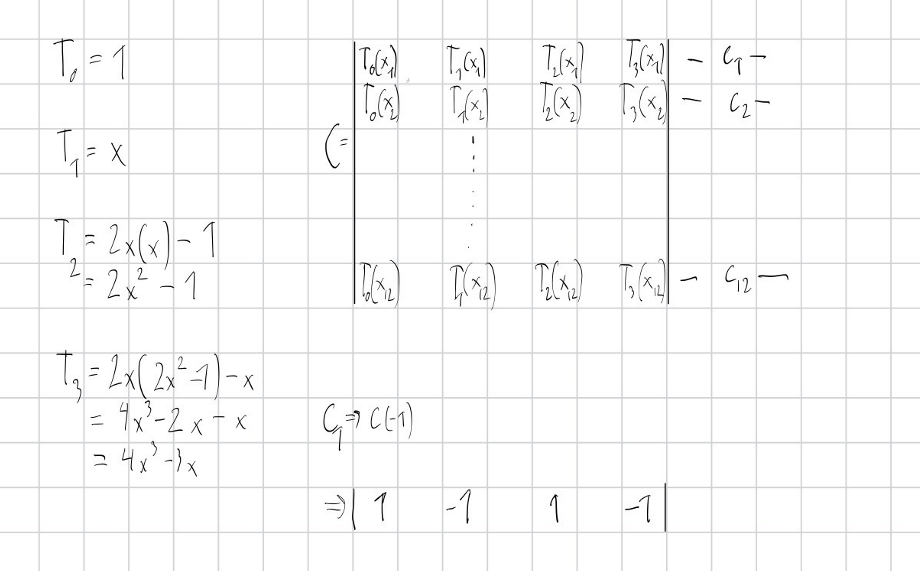

# Analyse
Når skyldes avviket at modellen ikke passer målingene, og når tyder kontrollene på problemer i beregningen?
- Vi bruker 3 forskjellige ting for å måle dette $|Q^TQ-I|_f$, $|A-QR|_f$ og residualen $r=b-Ac$.
- Hvis modellen ikke passer målingene får vi høy residual, dette kan skyldes støy i $b$, måleverdiene.
- Kontrollen kan tyde på problemer i beregningen, hvis en av de to kontrollene er høy. De måler ortonormalitet og rekonsturksjon av selve faktoriseringen $A=QR$
- Når vi økte støyet gikk residual økte også residual normen (del3 oppgave 3).
- Når vi byttet basis fra monomial til chebyshev, fikk vi lavere ortogonalitets feil og lavere maks avvik. Her ser vi at det skyldes feil i beregnignen.

Hva forteller residual, ortogonalitet og kurvefeil hver for seg?
- Residualen ($r=b-Ac)$ sier noe om forskjellen mellom målignene $b$ og modellverdiene i målepunktene.  En liten residual betyr at vi passer godt i målepunktene, hvis den er høy passer vi dårlig i målepunktene. Sier ingenting om det som skjer mellom punktene, så vi kan fortsatt ha stor kurveavvik
- ortogonalitet ($|Q^TQ-I|_f$) denne sjekker om kolonnene i $Q$ er ortonormale, den sier noe om numerisk pålitetlighet.
- Kurvefeilen sier noe om avviket fra den sanne kurven fra model kurven langs hele intervallet,

Hva endret du i redningsforsøket, og hvilke resultater støtter vurderingen?
- I forsøket endre jeg målepunktene, fra jevnt fordelt på intervallet til cosinus fordelt (chebyshev punkter).
- Vi fikk lavere maks avvik og kondisjonstall, men høyere residual.
- Dette betyr at modellen passer bedre til den sanne kurven, men vi får høyere feil i målepunktene, når det var støy i de.

Hvilken begrensning ved forsøket gjør at du bør være forsiktige med å generalisere?
- Vi sjekket ikke veldig mange seeds, så det kan være noe varriasjon fra seed til seed.
- Vi sjekket også bare et referanse polynom, en grad, og et sett punkter.